# Project Overview: Diabetic Retinopathy Debrecen

**Objective:** Predict multidimensional target classes and multi-level categorical outcomes simultaneously based on a comprehensive set of structured features, utilizing an ensemble learning paradigm optimized via balanced class weights and micro-averaged performance dynamics.

## 1. Libraries & Workspace Setup

In [2]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('diabetic-retinopathy-debrecen-challenge')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/diabetic-retinopathy-debrecen-challenge


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib
import pickle

## 2. Data Acquisition & Initial Inspection

### 2.1. Loading Train and Test Datasets

In [4]:
train_df=pd.read_csv('/kaggle/input/competitions/diabetic-retinopathy-debrecen-challenge/train.csv')
test_df=pd.read_csv('/kaggle/input/competitions/diabetic-retinopathy-debrecen-challenge/test.csv')

In [5]:
train_df.head()

,ID,quality,pre_screening,ma1,ma2,ma3,ma4,ma5,ma6,exudate1,...,exudate3,exudate4,exudate5,exudate6,exudate7,exudate8,macula_opticdsc_distance,opticdisc_diameter,am_fm_classification,Class
0,397,1,1,65,64,63,60,55,40,52.339677,...,5.894087,0.673435,0.016836,0.001531,0.000000,0.00000,0.536685,0.099485,0,1
1,288,1,1,87,80,69,57,44,27,127.089284,...,14.890506,3.147662,0.818002,0.029802,0.000000,0.00000,0.529809,0.155174,0,1
2,1071,1,1,15,15,14,13,10,7,71.522807,...,3.805837,0.438740,0.019522,0.001027,0.000000,0.00000,0.530780,0.114052,0,0
3,162,1,1,47,46,46,44,43,33,46.580741,...,4.016728,0.564756,0.128424,0.075817,0.060344,0.05106,0.517175,0.095931,0,0
4,1073,1,1,14,13,13,12,11,7,189.540803,...,19.351030,1.212168,0.050761,0.000000,0.000000,0.00000,0.530857,0.125887,0,1


In [6]:
test_df.head()

,ID,quality,pre_screening,ma1,ma2,ma3,ma4,ma5,ma6,exudate1,exudate2,exudate3,exudate4,exudate5,exudate6,exudate7,exudate8,macula_opticdsc_distance,opticdisc_diameter,am_fm_classification
0,4,1,1,55,53,53,50,43,31,40.467228,18.445954,9.118901,3.079428,0.840261,0.272434,0.007653,0.001531,0.483284,0.114790,0
1,12,1,0,25,25,25,23,22,18,22.480047,13.949995,0.436232,0.116119,0.000000,0.000000,0.000000,0.000000,0.551682,0.139657,1
2,13,1,1,70,69,65,63,63,50,10.560100,3.108358,0.625511,0.287959,0.103985,0.004799,0.000000,0.000000,0.534396,0.089587,0
3,14,1,1,48,43,39,32,27,18,23.012798,6.737583,2.403903,0.189235,0.011437,0.000000,0.000000,0.000000,0.501554,0.138287,1
4,20,1,0,46,41,39,32,23,15,115.533777,21.293312,9.665742,2.276676,0.329396,0.186000,0.118458,0.071698,0.540472,0.104949,1


### 2.2. Checking Structural Metadata

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 921 entries, 0 to 920
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        921 non-null    int64  
 1   quality                   921 non-null    int64  
 2   pre_screening             921 non-null    int64  
 3   ma1                       921 non-null    int64  
 4   ma2                       921 non-null    int64  
 5   ma3                       921 non-null    int64  
 6   ma4                       921 non-null    int64  
 7   ma5                       921 non-null    int64  
 8   ma6                       921 non-null    int64  
 9   exudate1                  921 non-null    float64
 10  exudate2                  921 non-null    float64
 11  exudate3                  921 non-null    float64
 12  exudate4                  921 non-null    float64
 13  exudate5                  921 non-null    float64
 14  exudate6  

In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        230 non-null    int64  
 1   quality                   230 non-null    int64  
 2   pre_screening             230 non-null    int64  
 3   ma1                       230 non-null    int64  
 4   ma2                       230 non-null    int64  
 5   ma3                       230 non-null    int64  
 6   ma4                       230 non-null    int64  
 7   ma5                       230 non-null    int64  
 8   ma6                       230 non-null    int64  
 9   exudate1                  230 non-null    float64
 10  exudate2                  230 non-null    float64
 11  exudate3                  230 non-null    float64
 12  exudate4                  230 non-null    float64
 13  exudate5                  230 non-null    float64
 14  exudate6  

In [9]:
train_df.isnull().sum()

ID                          0
quality                     0
pre_screening               0
ma1                         0
ma2                         0
ma3                         0
ma4                         0
ma5                         0
ma6                         0
exudate1                    0
exudate2                    0
exudate3                    0
exudate4                    0
exudate5                    0
exudate6                    0
exudate7                    0
exudate8                    0
macula_opticdsc_distance    0
opticdisc_diameter          0
am_fm_classification        0
Class                       0
dtype: int64

In [10]:
test_df.isnull().sum()

ID                          0
quality                     0
pre_screening               0
ma1                         0
ma2                         0
ma3                         0
ma4                         0
ma5                         0
ma6                         0
exudate1                    0
exudate2                    0
exudate3                    0
exudate4                    0
exudate5                    0
exudate6                    0
exudate7                    0
exudate8                    0
macula_opticdsc_distance    0
opticdisc_diameter          0
am_fm_classification        0
dtype: int64

## 3. Exploratory Data Analysis

In [13]:
train_df.select_dtypes(include=['int64', 'float64']).drop(columns=['ID'], errors='ignore').describe().T

,count,mean,std,min,25%,50%,75%,max
quality,921.0,0.995657,0.065795,0.000000,1.000000,1.000000,1.000000,1.000000
pre_screening,921.0,0.915309,0.278572,0.000000,1.000000,1.000000,1.000000,1.000000
ma1,921.0,38.403909,25.906474,1.000000,16.000000,35.000000,56.000000,151.000000
ma2,921.0,36.855592,24.321975,1.000000,16.000000,34.000000,53.000000,132.000000
ma3,921.0,35.089034,23.004742,1.000000,15.000000,32.000000,51.000000,120.000000
ma4,921.0,32.235613,21.258857,1.000000,14.000000,29.000000,48.000000,105.000000
ma5,921.0,28.664495,19.573200,1.000000,11.000000,25.000000,43.000000,97.000000
ma6,921.0,21.052117,15.019751,1.000000,8.000000,17.000000,32.000000,89.000000
exudate1,921.0,64.093091,57.822358,0.349274,22.276818,44.343736,87.929050,334.706269
exudate2,921.0,23.323954,21.720180,0.000000,7.864365,17.045113,31.674601,167.131427


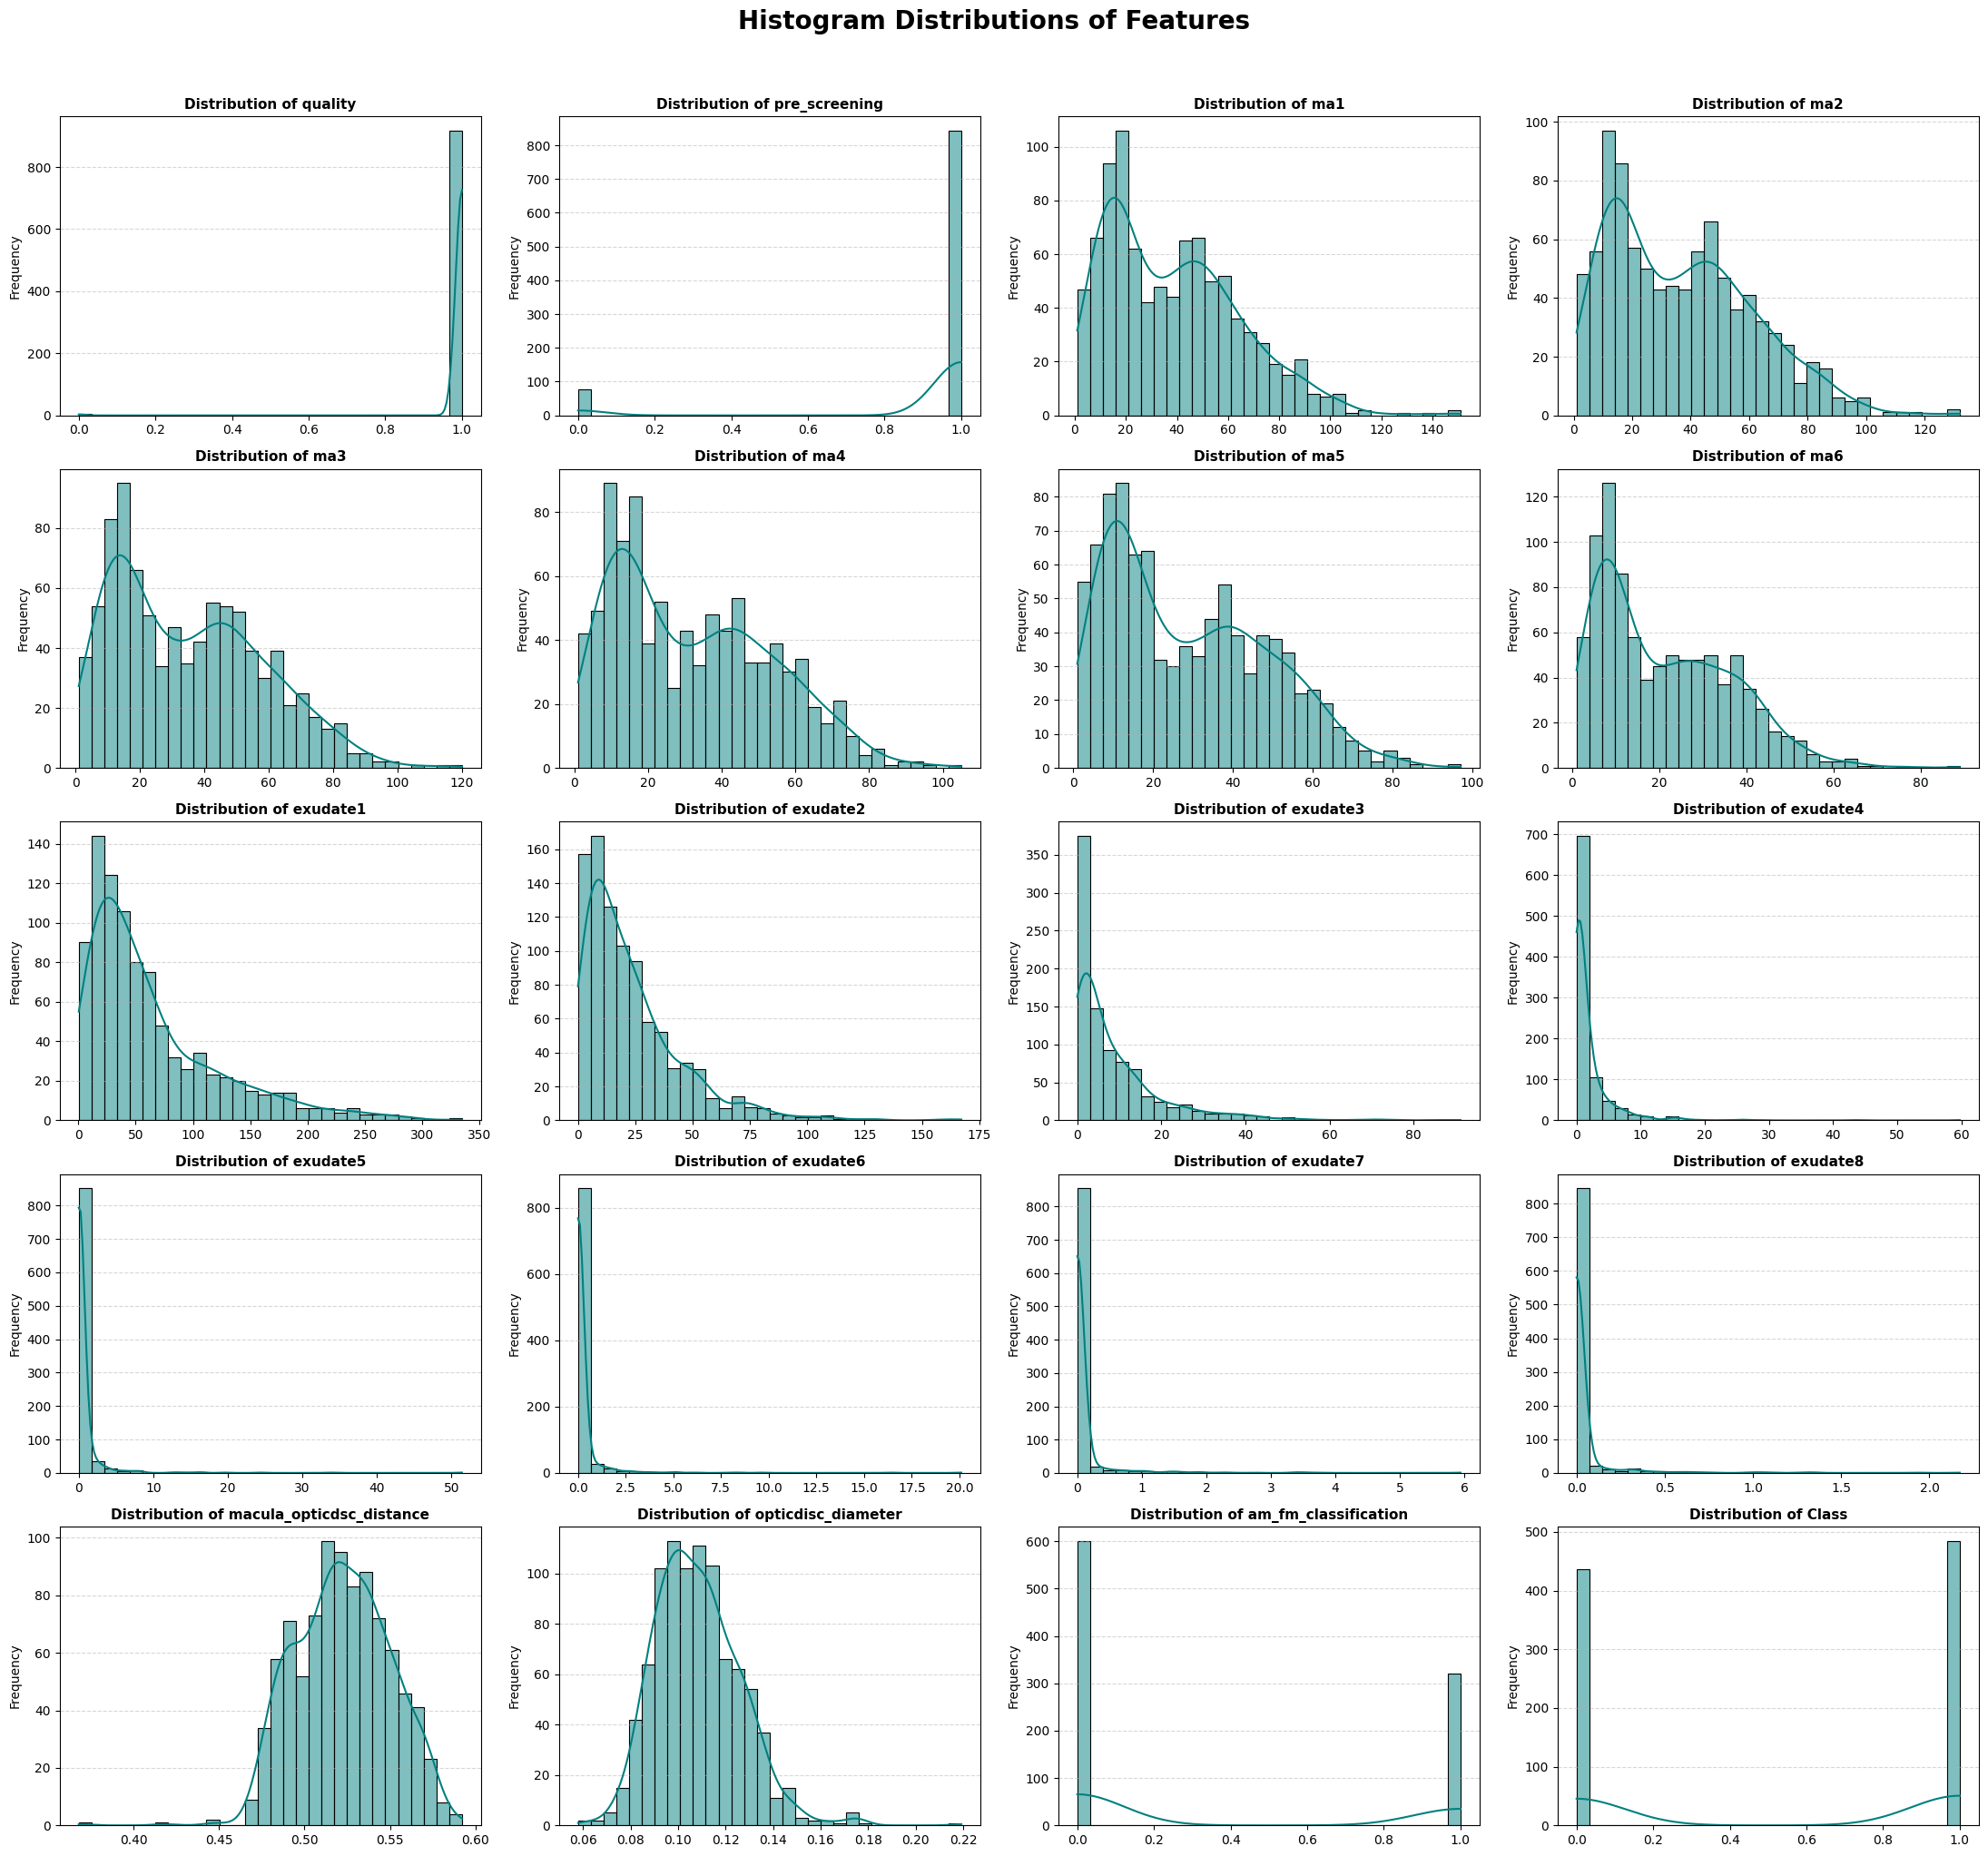

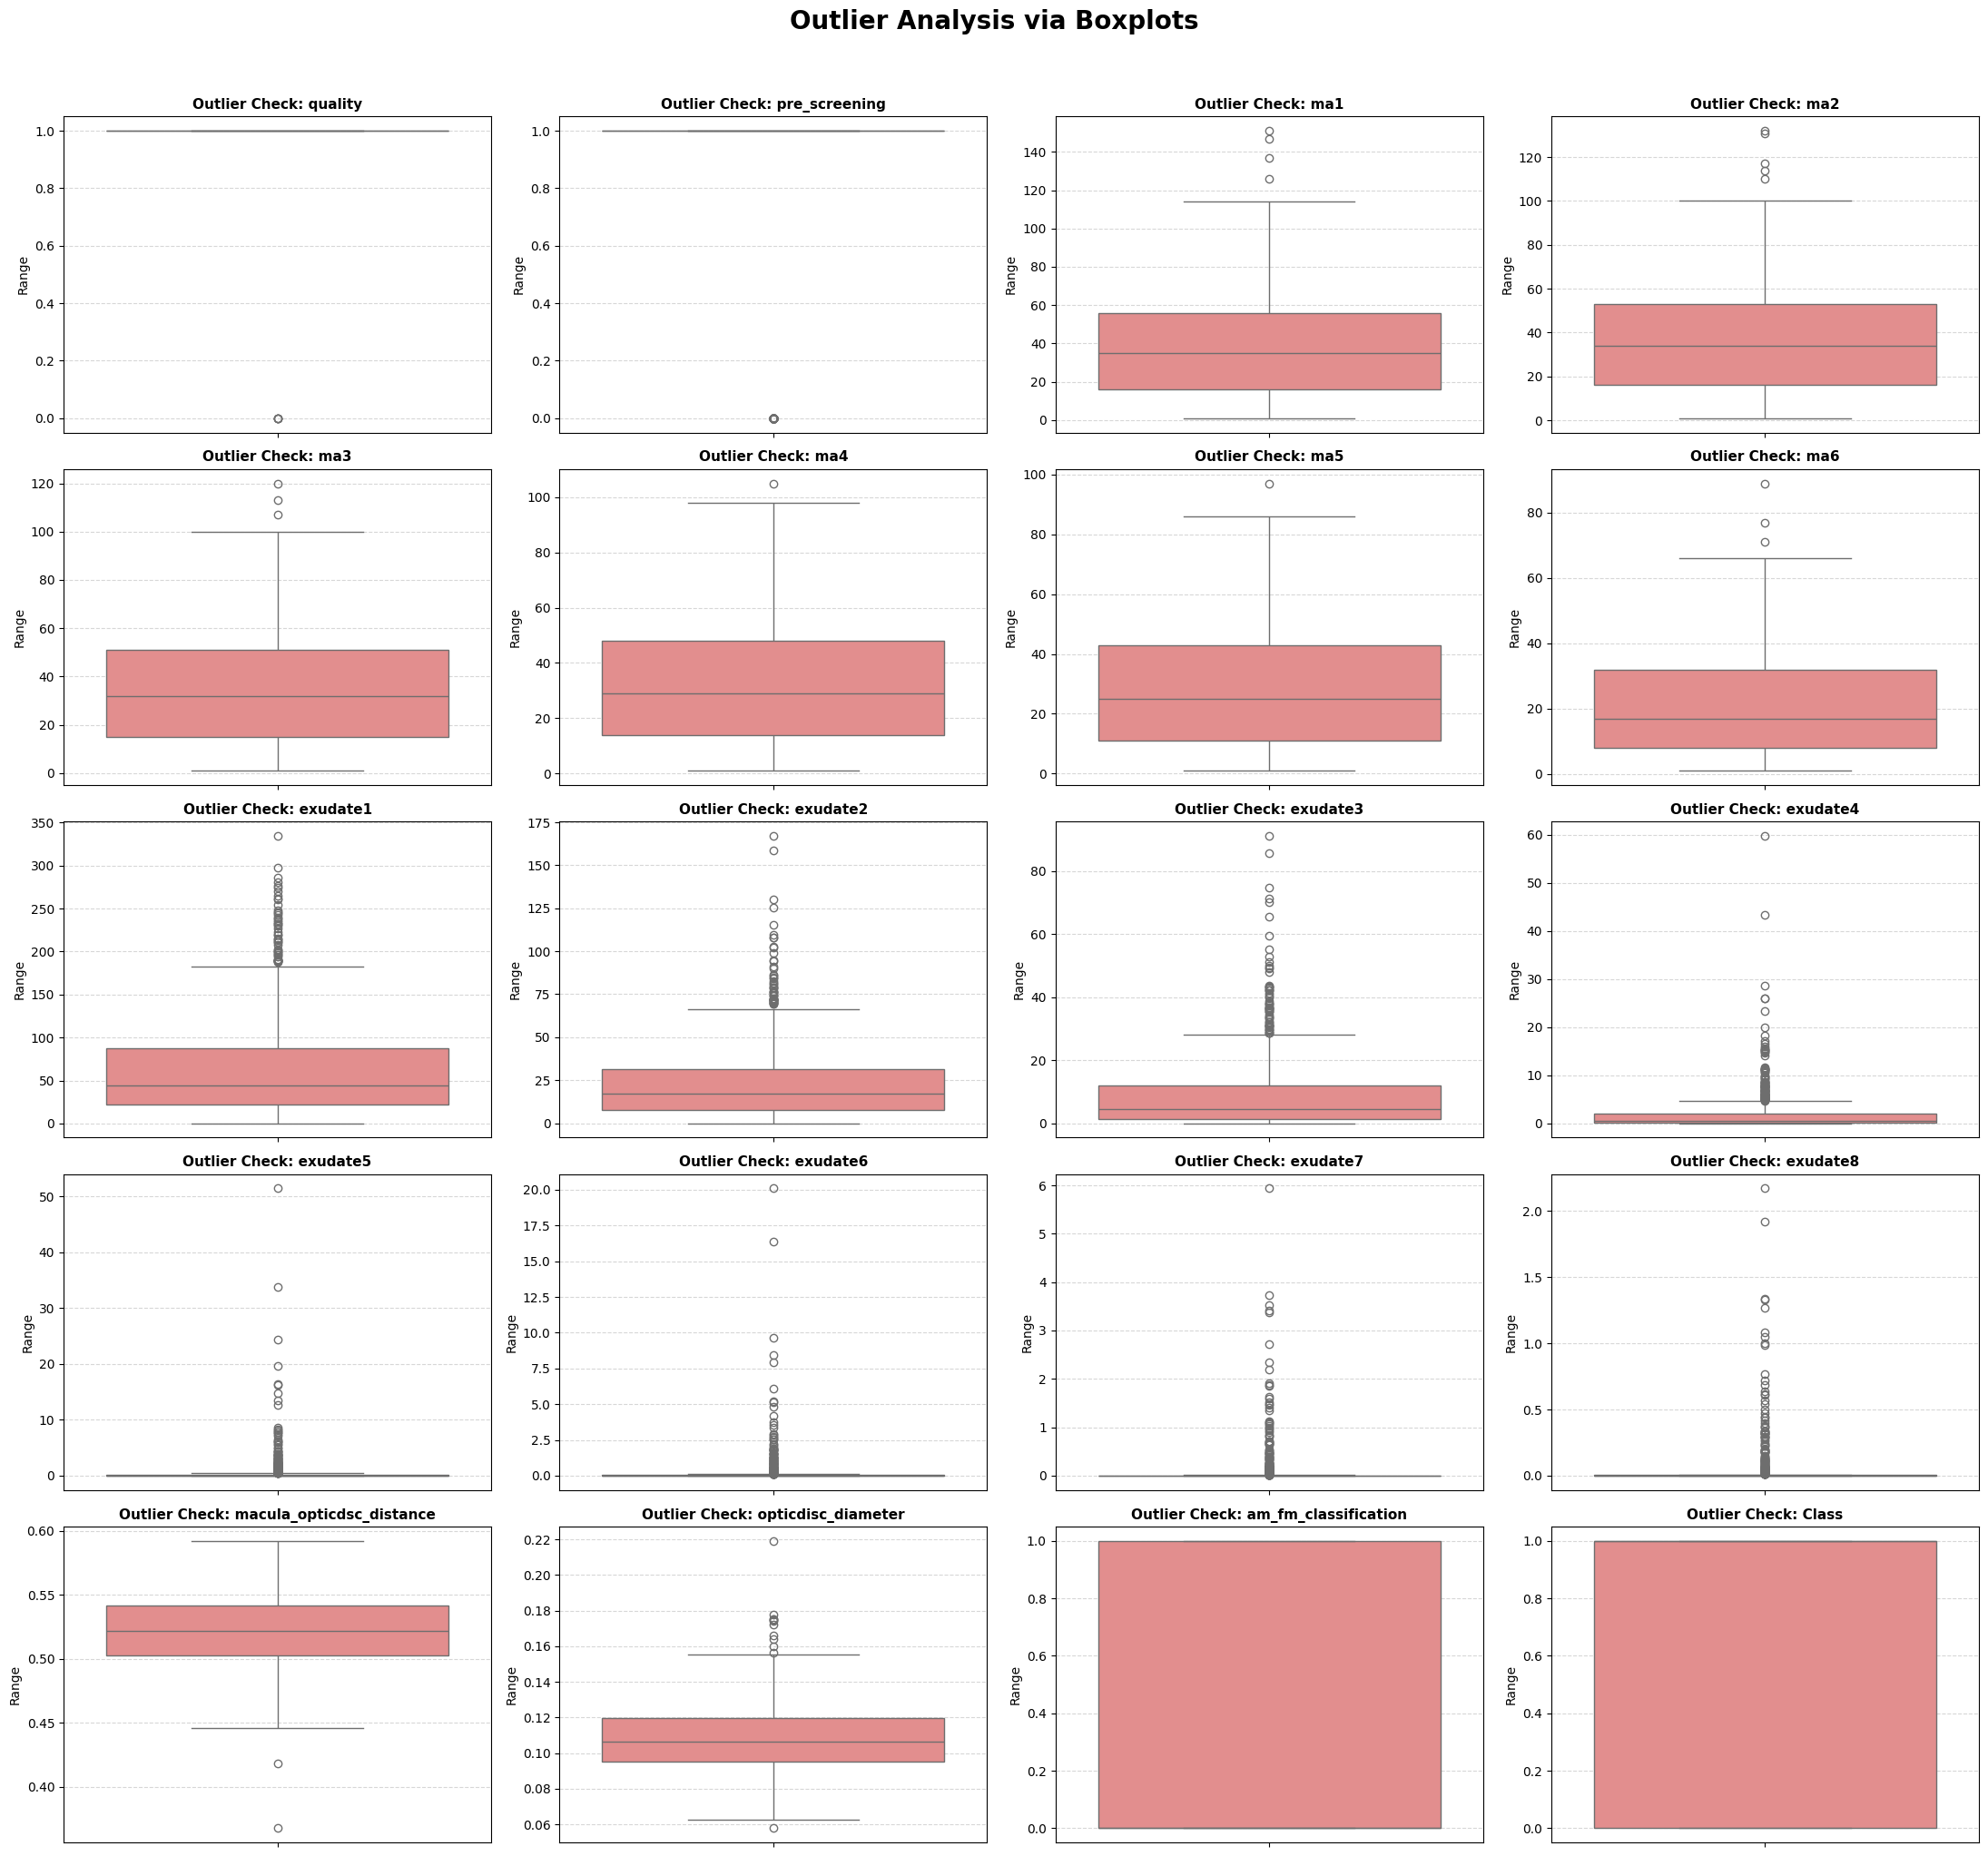

In [14]:
all_num_features = [col for col in train_df.select_dtypes(include=['int64', 'float64']).columns if col != 'ID']

nrows = 5
ncols = 4

# Histogram
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 20))
axes = axes.flatten()

for i, col in enumerate(all_num_features):
    sns.histplot(train_df[col], kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Histogram Distributions of Features', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Boxplot
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 20))
axes = axes.flatten()

for i, col in enumerate(all_num_features):
    sns.boxplot(y=train_df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Outlier Check: {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Range')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Outlier Analysis via Boxplots', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

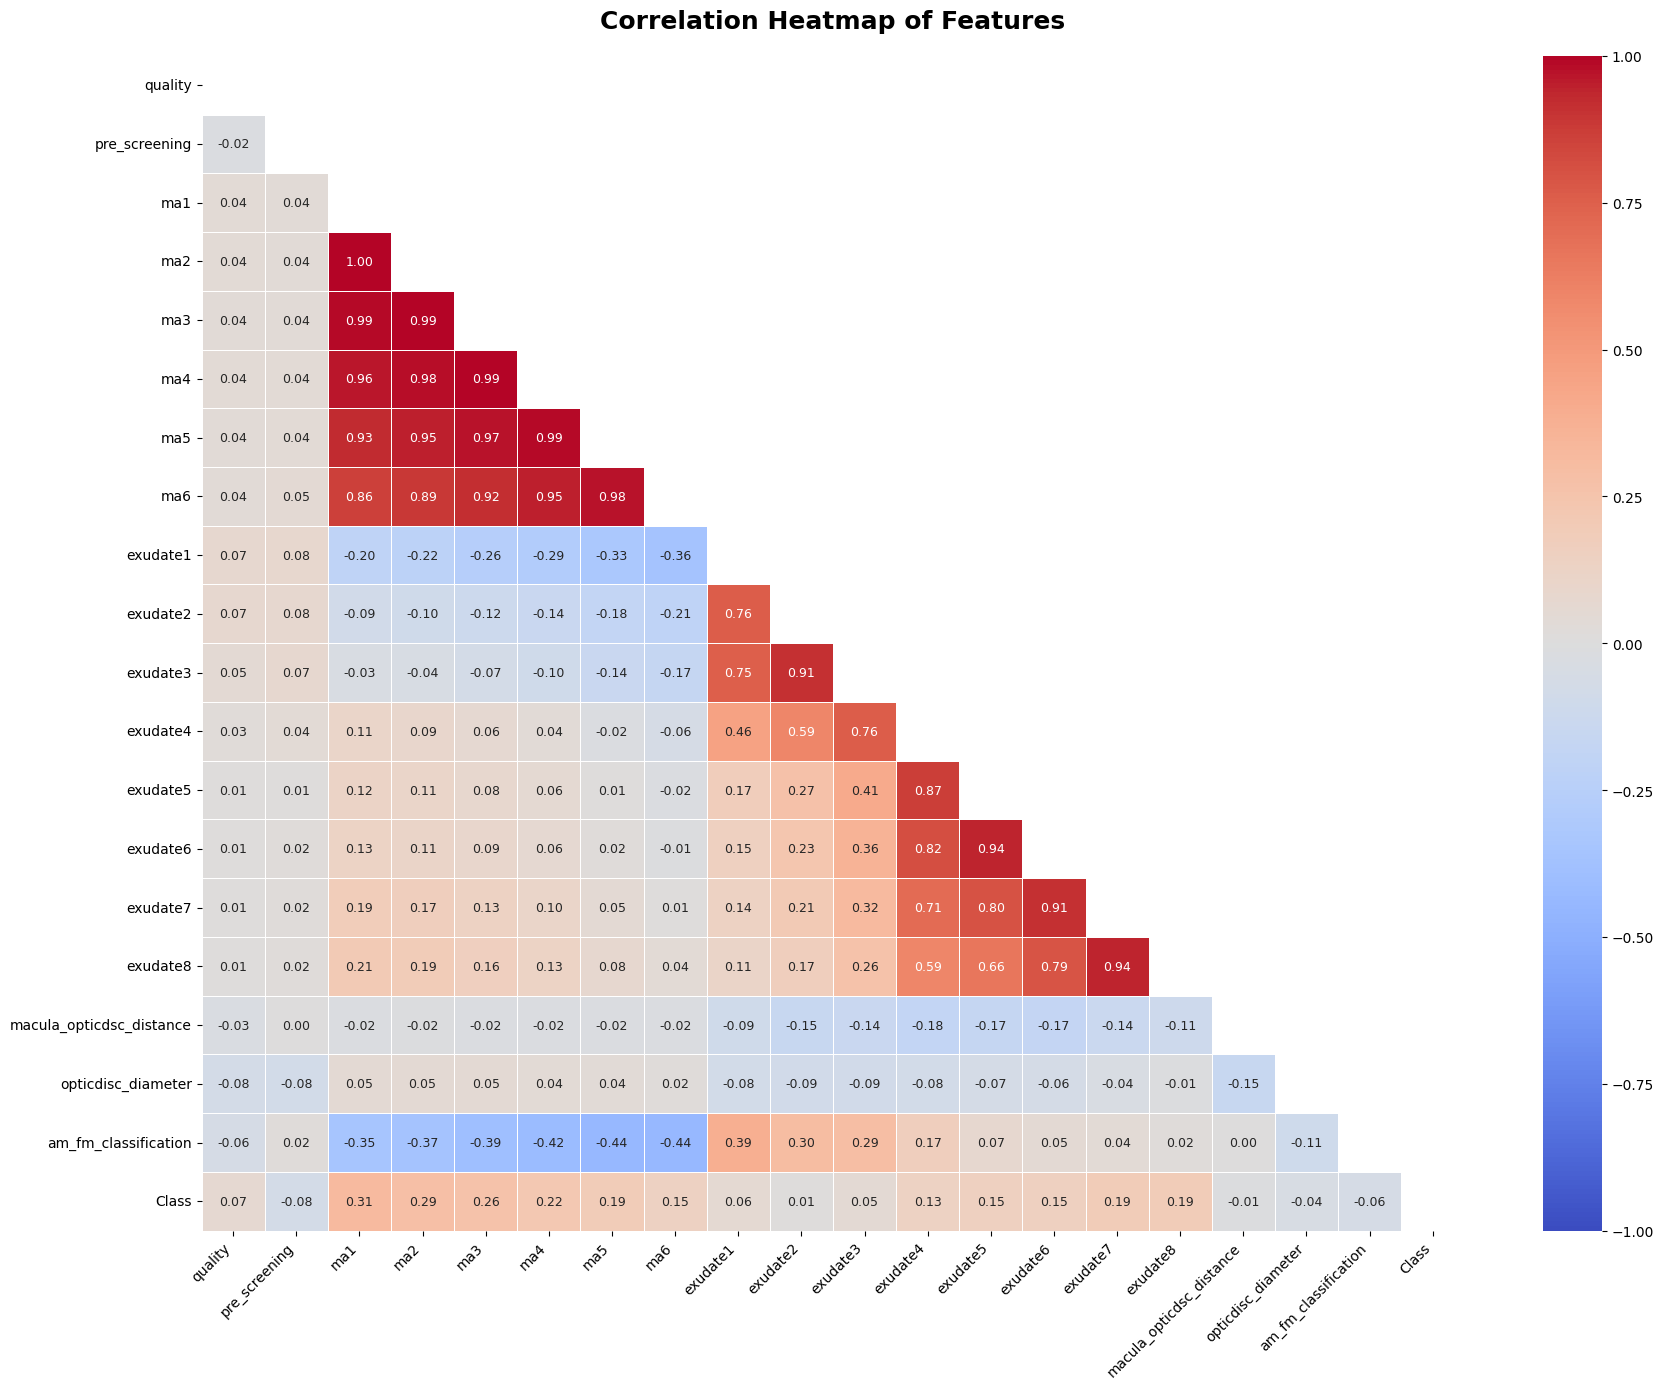

In [15]:
numeric_df = train_df.select_dtypes(include=['int64', 'float64']).drop(columns=['ID'], errors='ignore')

corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(18, 14))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f", 
            cmap='coolwarm',
            linewidths=0.5,
            annot_kws={"size": 9},
            vmax=1.0, vmin=-1.0)

plt.title('Correlation Heatmap of Features', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing & Feature Engineering (FE)

In [16]:
train_df['quality'].value_counts()

quality
1    917
0      4
Name: count, dtype: int64

In [17]:
test_df['quality'].value_counts()

quality
1    230
Name: count, dtype: int64

In [18]:
train_df['pre_screening'].value_counts()

pre_screening
1    843
0     78
Name: count, dtype: int64

In [19]:
test_df['pre_screening'].value_counts()

pre_screening
1    214
0     16
Name: count, dtype: int64

In [20]:
train_df['am_fm_classification'].value_counts()

am_fm_classification
0    601
1    320
Name: count, dtype: int64

In [21]:
test_df['am_fm_classification'].value_counts()

am_fm_classification
0    163
1     67
Name: count, dtype: int64

In [22]:
train_df['Class'].value_counts()

Class
1    485
0    436
Name: count, dtype: int64

In [23]:
train_df = train_df[train_df['quality'] != 0]

In [24]:
train_df = train_df.drop(columns=['quality'])

In [25]:
test_df = test_df.drop(columns=['quality'])

In [26]:
x_train_data = train_df.drop(columns=['ID', 'Class'], errors='ignore')
y_train_data = train_df['Class']
x_test_data = test_df.drop(columns=['ID', 'quality', 'Class'], errors='ignore')

## 5. Model Training, Optimization & Deployment Strategy

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def algo_test(x, y):
    b = BernoulliNB()
    l = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1, random_state=42)
    d = DecisionTreeClassifier(max_depth=15, class_weight='balanced', random_state=42)
    r = RandomForestClassifier(n_estimators=100, max_samples=0.2, class_weight='balanced', n_jobs=-1, random_state=42)
    gb = GradientBoostingClassifier(n_estimators=50, random_state=42)
    kn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    ab = AdaBoostClassifier(random_state=42)
    svc = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)
    xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, eval_metric='logloss', random_state=42)
    lgb = LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, class_weight='balanced', n_jobs=-1, random_state=42, verbose=-1)

    models = [b, l, d, r, gb, kn, ab, svc, xgb, lgb]
    model_names = [
        "BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
        "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
        "AdaBoostClassifier", "LinearSVC", "XGBClassifier", "LGBMClassifier"
    ]

    x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
        x, y, test_size=0.20, random_state=42, stratify=y
    )
    
    scaler = StandardScaler()
    x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train_split), columns=x_train_split.columns)
    x_val_scaled = pd.DataFrame(scaler.transform(x_val_split), columns=x_val_split.columns)
    
    accuracy, precision, recall, f1 = [], [], [], []
    successful_models = []
    successful_names = []

    
    for model, name in zip(models, model_names):
        print(f"--> Training {name}...")
        try:
            # Model Eğitimi (Dengeli veri olduğu için ekstra sample_weight yüklemesi kaldırıldı)
            model_fitted = model.fit(x_train_scaled, y_train_split)
                
            prediction = model_fitted.predict(x_val_scaled)
            
            accuracy.append(accuracy_score(y_val_split, prediction))
            precision.append(precision_score(y_val_split, prediction, zero_division=0))
            recall.append(recall_score(y_val_split, prediction, zero_division=0))
            f1.append(f1_score(y_val_split, prediction, zero_division=0))
            
            successful_models.append(model_fitted)
            successful_names.append(name)
            
        except Exception as e:
            print(f" [!] Error executing pipeline for {name}: {e}")
            continue

    metrics = pd.DataFrame(index=successful_names)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model_Object"] = successful_models

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("\n" + "="*50)
    best_model_name = metrics.index[0]
    print(f"TRUE MOST SUCCESSFUL MODEL BASED ON F1: {best_model_name}")
    print("="*50 + "\n")
    
    best_model_object = metrics.loc[best_model_name, "Model_Object"]
    final_prediction = best_model_object.predict(x_val_scaled)
    
    print(f"Real Confusion Matrix ({best_model_name}):")
    print(confusion_matrix(y_val_split, final_prediction))
    print(f"\nReal Classification Report ({best_model_name}):")
    print(classification_report(y_val_split, final_prediction))
    
    report_df = metrics.drop(columns=["Model_Object"])
    return report_df, metrics

In [28]:
report, full_metrics = algo_test(x_train_data, y_train_data)

--> Training BernoulliNB...
--> Training LogisticRegression...
--> Training DecisionTreeClassifier...
--> Training RandomForestClassifier...
--> Training GradientBoostingClassifier...
--> Training KNeighborsClassifier...
--> Training AdaBoostClassifier...
--> Training LinearSVC...
--> Training XGBClassifier...
--> Training LGBMClassifier...

TRUE MOST SUCCESSFUL MODEL BASED ON F1: LinearSVC

Real Confusion Matrix (LinearSVC):
[[74 13]
 [39 58]]

Real Classification Report (LinearSVC):
              precision    recall  f1-score   support

           0       0.65      0.85      0.74        87
           1       0.82      0.60      0.69        97

    accuracy                           0.72       184
   macro avg       0.74      0.72      0.72       184
weighted avg       0.74      0.72      0.71       184



In [29]:
report

,Accuracy,Precision,Recall,F1
LinearSVC,0.717391,0.816901,0.597938,0.690476
LGBMClassifier,0.695652,0.753086,0.628866,0.685393
GradientBoostingClassifier,0.663043,0.688172,0.659794,0.673684
XGBClassifier,0.657609,0.693182,0.628866,0.659459
AdaBoostClassifier,0.663043,0.705882,0.618557,0.659341
DecisionTreeClassifier,0.630435,0.659341,0.618557,0.638298
LogisticRegression,0.668478,0.764706,0.536082,0.630303
RandomForestClassifier,0.619565,0.655172,0.587629,0.619565
KNeighborsClassifier,0.625000,0.675000,0.556701,0.610169
BernoulliNB,0.603261,0.646341,0.546392,0.592179


In [30]:
x_raw_train, x_raw_val, y_raw_train, y_raw_val = train_test_split(x_train_data, y_train_data, test_size=0.20, random_state=42, stratify=y_train_data)

In [31]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_raw_train)
x_val_scaled = scaler.transform(x_raw_val)

In [32]:
model = LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)

In [33]:
model.fit(x_train_scaled, y_raw_train)

LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)

In [34]:
y_pred = model.predict(x_val_scaled)
y_scores = model.decision_function(x_val_scaled)

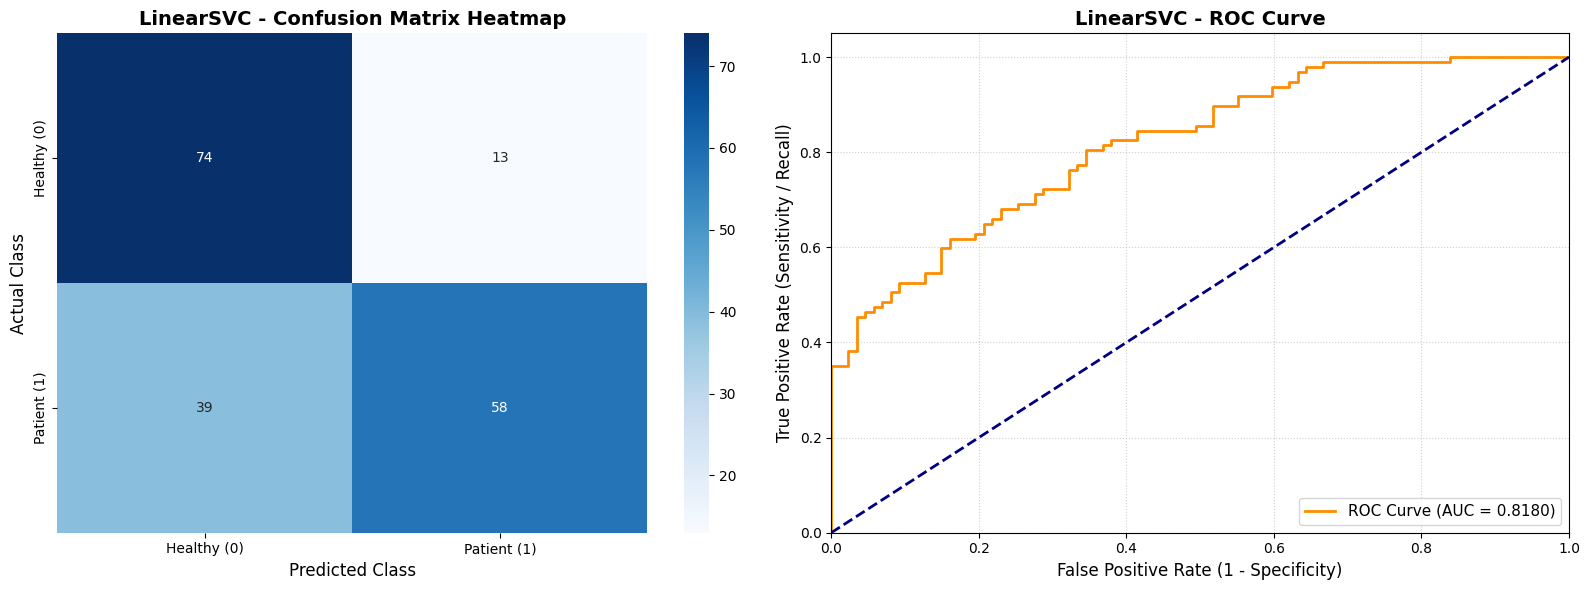

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_raw_val, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Healthy (0)', 'Patient (1)'],
            yticklabels=['Healthy (0)', 'Patient (1)'])

axes[0].set_title('LinearSVC - Confusion Matrix Heatmap', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Class', fontsize=12)
axes[0].set_ylabel('Actual Class', fontsize=12)


fpr, tpr, thresholds = roc_curve(y_raw_val, y_scores)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Rastgele tahmin çizgisi
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
axes[1].set_title('LinearSVC - ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [39]:
new_threshold = -0.2
y_pred_new = (y_scores > new_threshold).astype(int)

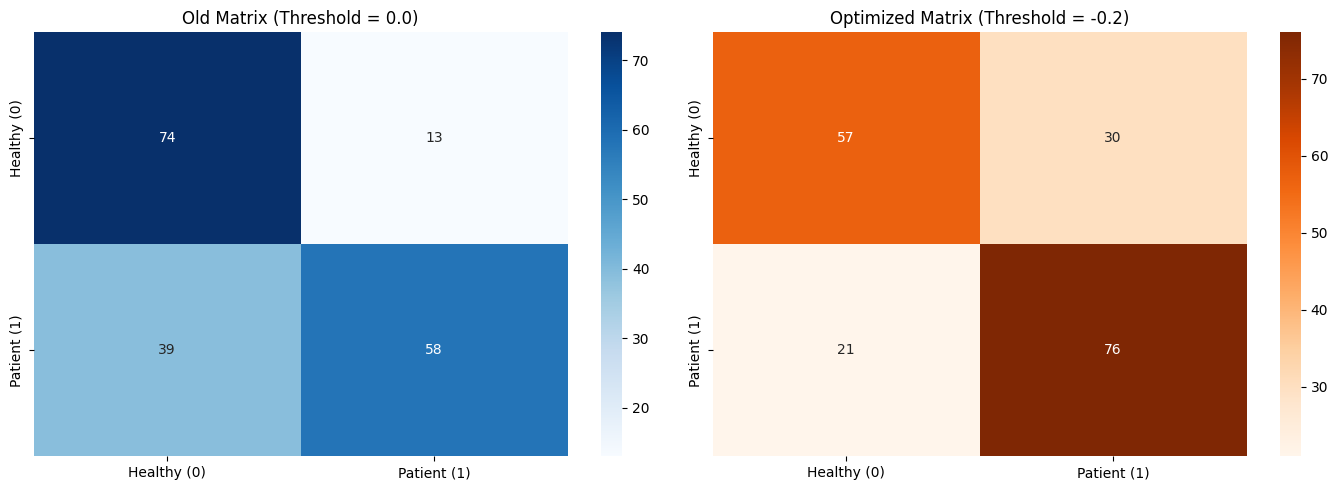

In [41]:
cm_new = confusion_matrix(y_raw_val, y_pred_new)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Healthy (0)', 'Patient (1)'], yticklabels=['Healthy (0)', 'Patient (1)'])
axes[0].set_title('Old Matrix (Threshold = 0.0)')

sns.heatmap(cm_new, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Healthy (0)', 'Patient (1)'], yticklabels=['Healthy (0)', 'Patient (1)'])
axes[1].set_title('Optimized Matrix (Threshold = -0.2)')

plt.tight_layout()
plt.show()

In [42]:
final_scaler = StandardScaler()
x_final_train_scaled = final_scaler.fit_transform(x_train_data)
x_final_test_scaled = final_scaler.transform(x_test_data)

In [43]:
final_model = LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)

In [44]:
final_model.fit(x_final_train_scaled, y_train_data)

LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)

In [45]:
test_decision_scores = final_model.decision_function(x_final_test_scaled)

In [46]:
optimized_threshold = -0.2
test_predictions_optimized = (test_decision_scores > optimized_threshold).astype(int)

In [52]:
submission_df = pd.DataFrame({
    'ID': test_df['ID'] if 'ID' in test_df.columns else test_df.index,
    'Class': test_predictions_optimized
})

submission_df.to_csv('optimized_predictions.csv', index=False)

In [48]:
model_filename = 'linearsvc_retinopathy_model.joblib'
scaler_filename = 'standard_scaler_retinopathy.joblib'

In [49]:
joblib.dump(final_model, model_filename, compress=3)
joblib.dump(final_scaler, scaler_filename, compress=3)

['standard_scaler_retinopathy.joblib']

In [50]:
with open('linearsvc_retinopathy_model.pkl', 'wb') as model_file:
    pickle.dump(final_model, model_file)

In [51]:
with open('standard_scaler_retinopathy.pkl', 'wb') as scaler_file:
    pickle.dump(final_scaler, scaler_file)